In [1]:
# Initial cell with imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [ ]:
# Data loading cell
# Fetch dataset
diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296)
 
# Data (as pandas dataframes)
X = diabetes_130_us_hospitals_for_years_1999_2008.data.features
y = diabetes_130_us_hospitals_for_years_1999_2008.data.targets

# Combine features and target
df = pd.concat([X, y], axis=1)

# Set pandas option to display all columns
pd.set_option('display.max_columns', None)

# print(X)

# columns_list = [col for col in X.columns]
# print(columns_list)

# print("First 5 rows of diabetesMed:")
# print(df['diabetesMed'].head())
# Display basic dataset information
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

['race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']
First 5 rows of diabetesMed:
0     No
1    Yes
2    Yes
3    Yes
4    Yes
Name: diabetesMed, dtype: object


c:\Users\AhmedAlrashid\AppData\Local\Programs\Python\Python313\Lib\site-packages\ucimlrepo\fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


Removing missing values

Features with missing values:
weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64


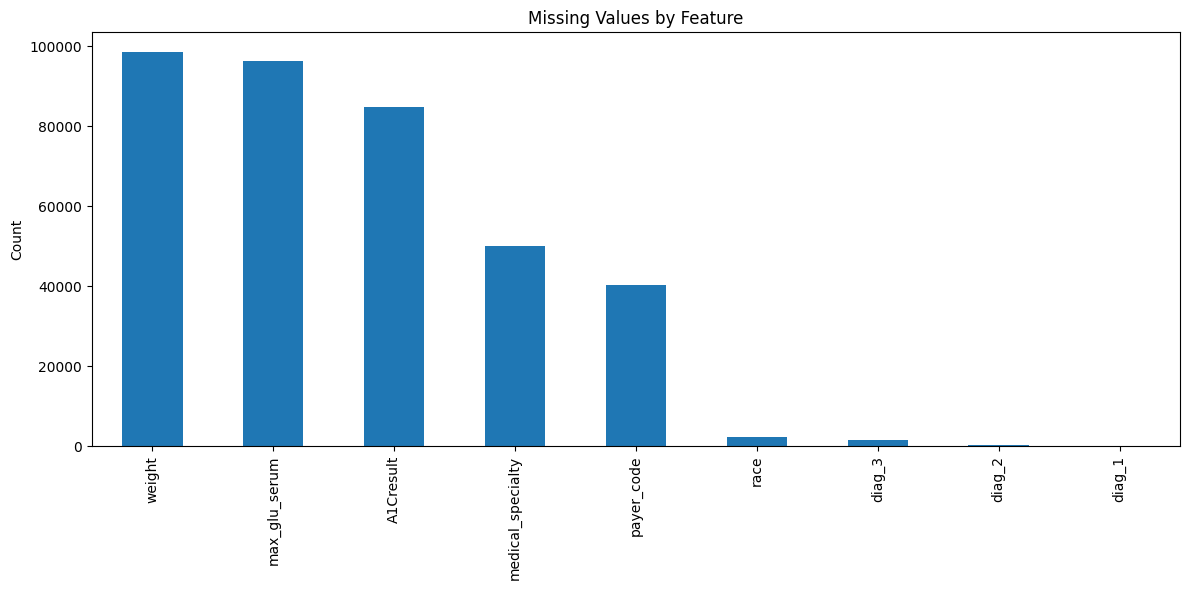

In [4]:
# Missing values analysis
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print("Features with missing values:")
print(missing_values)

# Visualize missing values
plt.figure(figsize=(12, 6))
missing_values.plot(kind='bar')
plt.title('Missing Values by Feature')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Readmission by Age Group
This visualization shows how readmission rates vary across different age groups.

Readmission counts:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


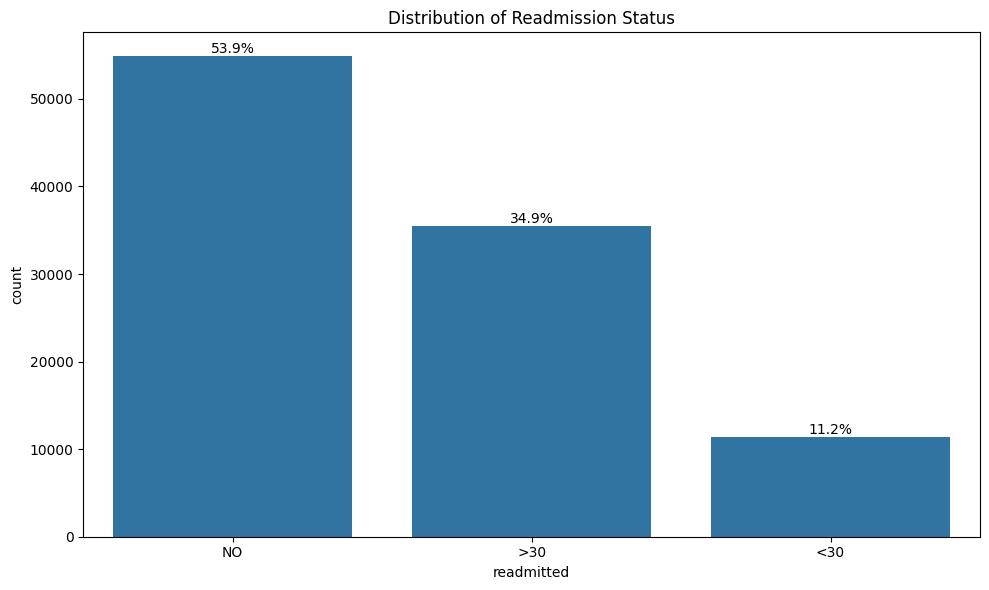

In [5]:
# Readmission status distribution
plt.figure(figsize=(10, 6))
readmission_counts = df['readmitted'].value_counts()
print("Readmission counts:")
print(readmission_counts)

ax = sns.countplot(x='readmitted', data=df)
plt.title('Distribution of Readmission Status')

# Add percentage labels
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

Age distribution

Age group counts:
age
[0-10)        161
[10-20)       691
[20-30)      1657
[30-40)      3775
[40-50)      9685
[50-60)     17256
[60-70)     22483
[70-80)     26068
[80-90)     17197
[90-100)     2793
Name: count, dtype: int64


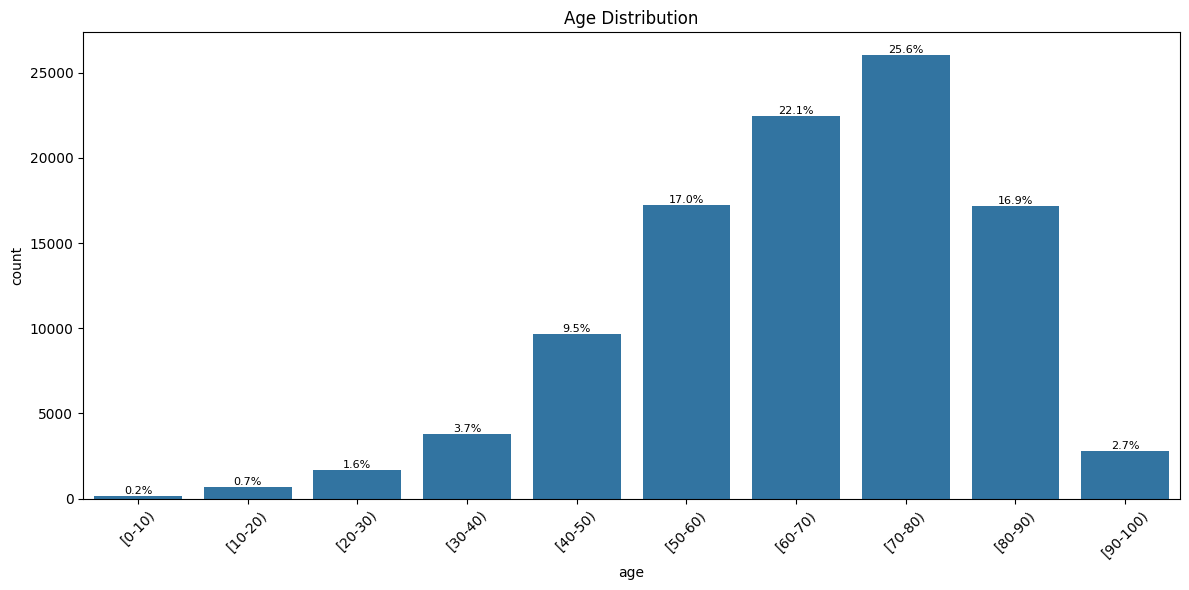

In [6]:
# Age distribution
plt.figure(figsize=(12, 6))
age_counts = df['age'].value_counts().sort_index()
print("Age group counts:")
print(age_counts)

ax = sns.countplot(x='age', data=df, order=age_counts.index)
plt.title('Age Distribution')
plt.xticks(rotation=45)

# Add percentage labels
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## Readmission by Age Group
This visualization shows how readmission rates vary across different age groups.

<Figure size 1400x700 with 0 Axes>

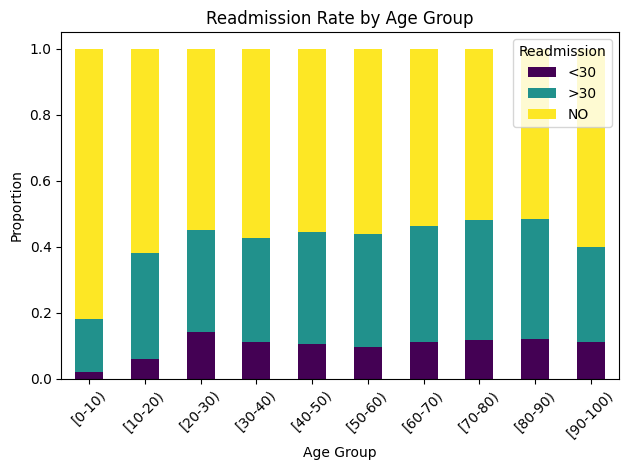

In [7]:
# Readmission by age group
plt.figure(figsize=(14, 7))
readmission_by_age = pd.crosstab(df['age'], df['readmitted'], normalize='index')
readmission_by_age.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Readmission Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.legend(title='Readmission')
plt.tight_layout()
plt.show()

Shows hospital readmission status total

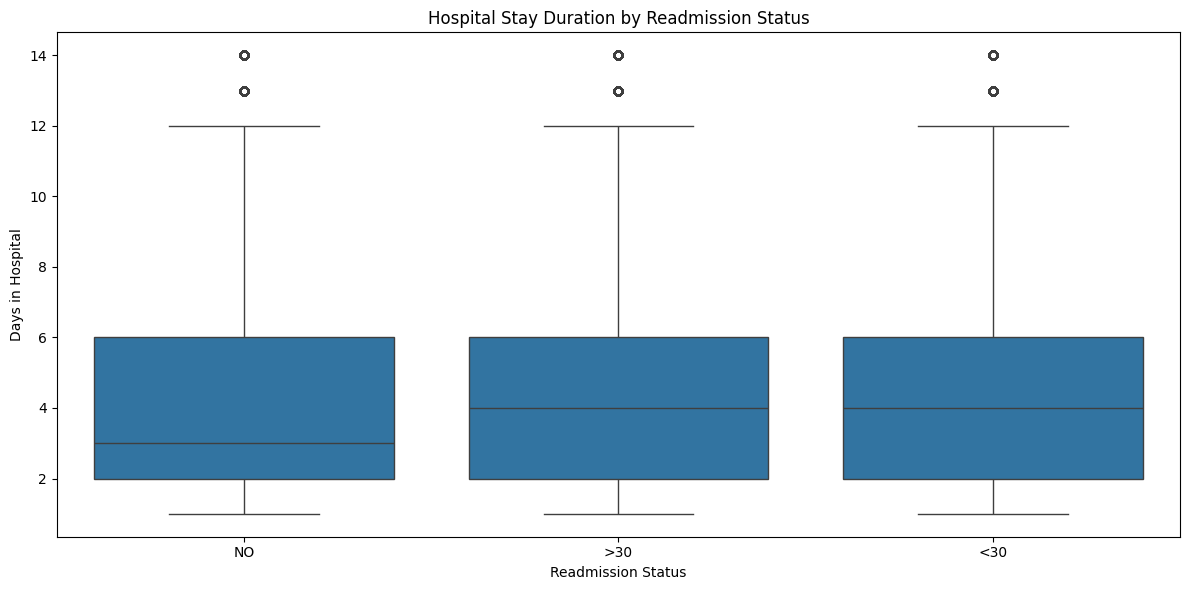

In [8]:
# Time in hospital analysis
plt.figure(figsize=(12, 6))
sns.boxplot(x='readmitted', y='time_in_hospital', data=df)
plt.title('Hospital Stay Duration by Readmission Status')
plt.xlabel('Readmission Status')
plt.ylabel('Days in Hospital')
plt.tight_layout()
plt.show()